# E337 - Grupo 1 - Trabajo Práctico 3
Integrantes: Constanza María Efkhanian - Julián Fabrizio Notario - María Florencia Pascale

## Bibliotecas

In [53]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
!pip install xlrd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import cut_tree
!pip install KModes
from kmodes.kmodes import KModes
from scipy import stats
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, 
                             recall_score, RocCurveDisplay, roc_auc_score)
from sklearn.metrics import ConfusionMatrixDisplay


## Directorio

In [17]:
directorio = r"C:\Users\HP\OneDrive\Documentos\Programación\E337_Grupo1\TP3"
os.chdir(directorio)
print(os.getcwd())

C:\Users\HP\OneDrive\Documentos\Programación\E337_Grupo1\TP3


In [18]:
# Abrimos el csv. 
ocupados = pd.read_csv('ocupados.csv')

In [19]:
# Agregamos variables que no se guardaron en el csv.

# 'educ'

educ_map = {
    1: 0,   # Sin instrucción
    2: 6,   # Primaria incompleta
    3: 6,   # Primaria completa
    4: 9,   # Secundaria incompleta
    5: 12,  # Secundaria completa
    6: 14,  # Superior/universitaria incompleta
    7: 17,  # Superior/universitaria completa
}
ocupados['educ'] = ocupados['NIVEL_ED'].map(educ_map)

# 'horastrab'
ocupados['horastrab'] = pd.to_numeric(ocupados['PP3E_TOT'], errors='coerce')

## A. Enfoque de Validación

### 1. 

In [20]:
# Separamos las bases de datos.
ocupados_2005 = ocupados[ocupados['ANO4'] == 2005].copy()
ocupados_2025 = ocupados[ocupados['ANO4'] == 2025].copy()

# Nos aseguramos de que se hayan separado correctamente
print("ocupados_2005:", len(ocupados_2005), "filas")
print("ocupados_2025:", len(ocupados_2025), "filas")
print("Total:", len(ocupados_2005) + len(ocupados_2025), "(debe coincidir con", len(ocupados), ")")

# Nos aseguramos de que las variables nuevas hayan sido creadas correctamente.
print("Variables recreadas:")
print("  educ     - NaN:", ocupados['educ'].isna().sum())
print("  horastrab - NaN:", ocupados['horastrab'].isna().sum())

ocupados_2005: 4088 filas
ocupados_2025: 3537 filas
Total: 7625 (debe coincidir con 7625 )
Variables recreadas:
  educ     - NaN: 0
  horastrab - NaN: 67


### 2. 

In [21]:
vars_X = {
    'CH06':                  'Edad',
    'edad2':                 'Edad²',
    'educ':                  'Años de educación',
    'ingreso_total_familiar':'Ingreso total familiar',
    'IX_TOT':                'Personas en el hogar',
    'horastrab':             'Horas trabajadas',
}

filas = []

for var, nombre in vars_X.items():
    serie_2005 = ocupados_2005[var].dropna()
    serie_2025 = ocupados_2025[var].dropna()
    
    media_2005 = serie_2005.mean()
    media_2025 = serie_2025.mean()
    diferencia = media_2025 - media_2005
    
    # T-test de diferencia de medias (varianzas no necesariamente iguales)
    t_stat, p_valor = stats.ttest_ind(serie_2025, serie_2005, equal_var=False)
    
    significativa = '***' if p_valor < 0.01 else ('**' if p_valor < 0.05 else ('*' if p_valor < 0.10 else ''))
    
    filas.append({
        'Variable':       nombre,
        'Media 2005':     round(media_2005, 2),
        'Media 2025':     round(media_2025, 2),
        'Diferencia':     round(diferencia, 2),
        'p-valor':        round(p_valor, 4),
        'Significancia':  significativa,
    })

tabla_medias = pd.DataFrame(filas).set_index('Variable')
print(tabla_medias.to_string())
print("\n*** p<0.01  ** p<0.05  * p<0.10")


                        Media 2005  Media 2025  Diferencia  p-valor Significancia
Variable                                                                         
Edad                         39.93       42.52        2.59   0.0000           ***
Edad²                      1791.88     2010.76      218.88   0.0000           ***
Años de educación             8.71        9.71        1.01   0.0000           ***
Ingreso total familiar  2576031.15  2298456.99  -277574.16   0.0001           ***
Personas en el hogar          3.86        3.46       -0.40   0.0000           ***
Horas trabajadas             39.17       35.88       -3.29   0.0000           ***

*** p<0.01  ** p<0.05  * p<0.10


### 3. 

In [22]:
vars_X = ['CH06', 'edad2', 'educ', 'ingreso_total_familiar', 'IX_TOT', 'horastrab']

# 2005
df_2005_modelo = ocupados_2005[vars_X + ['informal']].dropna()

X_2005 = df_2005_modelo[vars_X].copy()
X_2005.insert(0, 'const', 1)          # columna de unos para el intercept
y_2005 = df_2005_modelo['informal']

X_2005_train, X_2005_test, y_2005_train, y_2005_test = train_test_split(
    X_2005, y_2005, test_size=0.30, random_state=444
)

# 2025
df_2025_modelo = ocupados_2025[vars_X + ['informal']].dropna()

X_2025 = df_2025_modelo[vars_X].copy()
X_2025.insert(0, 'const', 1)          # columna de unos para el intercept
y_2025 = df_2025_modelo['informal']

X_2025_train, X_2025_test, y_2025_train, y_2025_test = train_test_split(
    X_2025, y_2025, test_size=0.30, random_state=444
)

# Verificación
print("2005:")
print(f"  Train: {len(X_2005_train)} obs ({len(X_2005_train)/len(X_2005)*100:.1f}%)")
print(f"  Test:  {len(X_2005_test)} obs ({len(X_2005_test)/len(X_2005)*100:.1f}%)")

print("\n2025:")
print(f"  Train: {len(X_2025_train)} obs ({len(X_2025_train)/len(X_2025)*100:.1f}%)")
print(f"  Test:  {len(X_2025_test)} obs ({len(X_2025_test)/len(X_2025)*100:.1f}%)")

# Exportamos tabla a LaTeX
latex_tabla = tabla_medias.to_latex(
    caption='Diferencia de medias entre ocupados 2005 y 2025',
    label='tab:diff_medias',
    column_format='lrrrrl',
    escape=False,       
    na_rep='--'
)

print(latex_tabla)

# Guardamos archivo como .tex
with open('tabla_diff_medias.tex', 'w', encoding='utf-8') as f:
    f.write(latex_tabla)
print("\nArchivo 'tabla_diff_medias.tex' se guardó correctamente.")

2005:
  Train: 2844 obs (70.0%)
  Test:  1220 obs (30.0%)

2025:
  Train: 1249 obs (70.0%)
  Test:  536 obs (30.0%)
\begin{table}
\caption{Diferencia de medias entre ocupados 2005 y 2025}
\label{tab:diff_medias}
\begin{tabular}{lrrrrl}
\toprule
 & Media 2005 & Media 2025 & Diferencia & p-valor & Significancia \\
Variable &  &  &  &  &  \\
\midrule
Edad & 39.930000 & 42.520000 & 2.590000 & 0.000000 & *** \\
Edad² & 1791.880000 & 2010.760000 & 218.880000 & 0.000000 & *** \\
Años de educación & 8.710000 & 9.710000 & 1.010000 & 0.000000 & *** \\
Ingreso total familiar & 2576031.150000 & 2298456.990000 & -277574.160000 & 0.000100 & *** \\
Personas en el hogar & 3.860000 & 3.460000 & -0.400000 & 0.000000 & *** \\
Horas trabajadas & 39.170000 & 35.880000 & -3.290000 & 0.000000 & *** \\
\bottomrule
\end{tabular}
\end{table}


Archivo 'tabla_diff_medias.tex' se guardó correctamente.


## B. Modelo de Regresión Logística

### 1.

In [23]:
# Realizamos la estimación
logit_2005 = sm.Logit(y_2005_train, X_2005_train).fit()
logit_2025 = sm.Logit(y_2025_train, X_2025_train).fit()

print(logit_2005.summary())
print(logit_2025.summary())

Optimization terminated successfully.
         Current function value: 0.569733
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.488264
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               informal   No. Observations:                 2844
Model:                          Logit   Df Residuals:                     2837
Method:                           MLE   Df Model:                            6
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.1199
Time:                        13:06:32   Log-Likelihood:                -1620.3
converged:                       True   LL-Null:                       -1841.1
Covariance Type:            nonrobust   LLR p-value:                 3.250e-92
                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [24]:
def construir_tabla_logit(modelo, año):
    coef   = modelo.params
    se     = modelo.bse
    oddr   = np.exp(modelo.params)
    pvals  = modelo.pvalues

    sig = pvals.apply(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')))

    tabla = pd.DataFrame({
        f'Coef. {año}':   coef.round(4),
        f'SE {año}':      se.round(4),
        f'OR {año}':      oddr.round(4),
        f'Sig. {año}':    sig,
    })
    return tabla

tabla_2005 = construir_tabla_logit(logit_2005, '2005')
tabla_2025 = construir_tabla_logit(logit_2025, '2025')

tabla_logit = tabla_2005.join(tabla_2025)

# Renombramos el índice para que quede prolijo
nombres = {
    'const':                  'Intercepto',
    'CH06':                   'Edad',
    'edad2':                  'Edad²',
    'educ':                   'Años de educación',
    'ingreso_total_familiar': 'Ingreso total familiar',
    'IX_TOT':                 'Personas en el hogar',
    'horastrab':              'Horas trabajadas',
}
tabla_logit.index = tabla_logit.index.map(nombres)

print(tabla_logit.to_string())
print("\n*** p<0.01  ** p<0.05  * p<0.10")

                        Coef. 2005  SE 2005  OR 2005 Sig. 2005  Coef. 2025  SE 2025   OR 2025 Sig. 2025
Intercepto                  3.9990   0.3905  54.5409       ***      4.8740   0.6739  130.8468       ***
Edad                       -0.1111   0.0173   0.8948       ***     -0.1919   0.0289    0.8254       ***
Edad²                       0.0010   0.0002   1.0010       ***      0.0020   0.0003    1.0020       ***
Años de educación          -0.1275   0.0135   0.8803       ***     -0.1154   0.0236    0.8910       ***
Ingreso total familiar     -0.0000   0.0000   1.0000       ***     -0.0000   0.0000    1.0000       ***
Personas en el hogar        0.0574   0.0230   1.0591        **      0.1001   0.0505    1.1053        **
Horas trabajadas           -0.0241   0.0023   0.9762       ***     -0.0079   0.0040    0.9922        **

*** p<0.01  ** p<0.05  * p<0.10


In [47]:
# Exportar a LaTeX 

latex_logit = tabla_logit.to_latex(
    caption='Regresión Logística: coeficientes, errores estándar y odd-ratios (2005 vs 2025)',
    label='tab:logit',
    column_format='l' + 'rrrr' * 2,
    escape=False,
    na_rep='--'
)

print(latex_logit)

with open('tabla_logit.tex', 'w', encoding='utf-8') as f:
    f.write(latex_logit)
print("Archivo 'tabla_logit.tex' se guardó correctamente.")

\begin{table}
\caption{Regresión Logística: coeficientes, errores estándar y odd-ratios (2005 vs 2025)}
\label{tab:logit}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Coef. 2005 & SE 2005 & OR 2005 & Sig. 2005 & Coef. 2025 & SE 2025 & OR 2025 & Sig. 2025 \\
\midrule
Intercepto & 3.999000 & 0.390500 & 54.540900 & *** & 4.874000 & 0.673900 & 130.846800 & *** \\
Edad & -0.111100 & 0.017300 & 0.894800 & *** & -0.191900 & 0.028900 & 0.825400 & *** \\
Edad² & 0.001000 & 0.000200 & 1.001000 & *** & 0.002000 & 0.000300 & 1.002000 & *** \\
Años de educación & -0.127500 & 0.013500 & 0.880300 & *** & -0.115400 & 0.023600 & 0.891000 & *** \\
Ingreso total familiar & -0.000000 & 0.000000 & 1.000000 & *** & -0.000000 & 0.000000 & 1.000000 & *** \\
Personas en el hogar & 0.057400 & 0.023000 & 1.059100 & ** & 0.100100 & 0.050500 & 1.105300 & ** \\
Horas trabajadas & -0.024100 & 0.002300 & 0.976200 & *** & -0.007900 & 0.004000 & 0.992200 & ** \\
\bottomrule
\end{tabular}
\end{table}

Archivo 'tabla_logit.tex

### 2. 

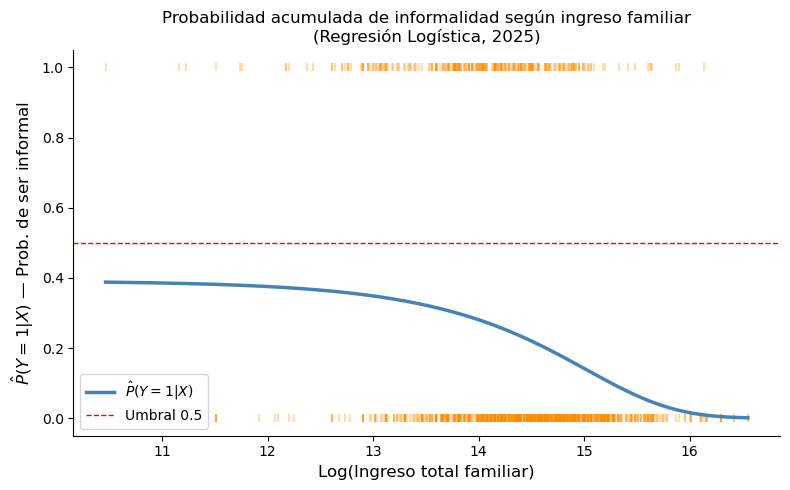

In [26]:
medias_2025 = X_2025_train.mean()
ocupados['log_ingreso'] = np.log1p(ocupados['ingreso_total_familiar'])

# Agregar log_ingreso al X_train de 2025
X_2025_train_plot = X_2025_train.copy()
X_2025_train_plot['log_ingreso'] = np.log1p(
    df_2025_modelo.loc[X_2025_train.index, 'ingreso_total_familiar']
)

var_plot   = 'ingreso_total_familiar'
label_plot = 'Ingreso total familiar (log escala)'

log_grilla = np.linspace(
    np.log1p(X_2025_train[var_plot].min()),
    np.log1p(X_2025_train[var_plot].max()),
    300
)

# Reconstruimos la grilla sobre el X original
X_grilla = pd.DataFrame([medias_2025] * len(log_grilla), columns=X_2025_train.columns)
X_grilla[var_plot] = np.expm1(log_grilla)   # volvemos a escala original para predecir

prob_predicha = logit_2025.predict(X_grilla)

# Separamos informales/formales
mask_1 = y_2025_train == 1
mask_0 = y_2025_train == 0

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(np.log1p(X_2025_train.loc[mask_1, var_plot]), np.ones(mask_1.sum()),
           marker='|', color='darkorange', alpha=0.3, s=40)
ax.scatter(np.log1p(X_2025_train.loc[mask_0, var_plot]), np.zeros(mask_0.sum()),
           marker='|', color='darkorange', alpha=0.3, s=40)

ax.plot(log_grilla, prob_predicha, color='steelblue', linewidth=2.5,
        label='$\hat{P}(Y=1|X)$')

ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Umbral 0.5')
ax.set_xlabel('Log(Ingreso total familiar)', fontsize=12)
ax.set_ylabel('$\hat{P}(Y=1|X)$ — Prob. de ser informal', fontsize=12)
ax.set_title('Probabilidad acumulada de informalidad según ingreso familiar\n(Regresión Logística, 2025)', fontsize=12)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('logit_prob_ingreso_2025.png', dpi=300, bbox_inches='tight')
plt.show()

## C. Método de Vecinos Cercanos (KNN)

### 3. 

In [27]:
# KNN no necesita la columna 'const' ni el intercepto
features = ['CH06', 'edad2', 'educ', 'ingreso_total_familiar', 'IX_TOT', 'horastrab']

X_2005_train_knn = X_2005_train[features]
X_2005_test_knn  = X_2005_test[features]
X_2025_train_knn = X_2025_train[features]
X_2025_test_knn  = X_2025_test[features]

# Escalamos 
scaler_2005 = StandardScaler()
X_2005_train_scaled = scaler_2005.fit_transform(X_2005_train_knn)
X_2005_test_scaled  = scaler_2005.transform(X_2005_test_knn)

scaler_2025 = StandardScaler()
X_2025_train_scaled = scaler_2025.fit_transform(X_2025_train_knn)
X_2025_test_scaled  = scaler_2025.transform(X_2025_test_knn)

# Estimación para K = {10, 50, 100}
Ks = [10, 50, 100]
knn_modelos = {}

print("Accuracy en test (Accuracy = (TP+TN)/N):")
print(f"{'K':>5} | {'2005 Train':>12} | {'2005 Test':>10} | {'2025 Train':>12} | {'2025 Test':>10}")
print("-" * 60)

for k in Ks:
    knn_05 = KNeighborsClassifier(n_neighbors=k)
    knn_05.fit(X_2005_train_scaled, y_2005_train)

    knn_25 = KNeighborsClassifier(n_neighbors=k)
    knn_25.fit(X_2025_train_scaled, y_2025_train)

    knn_modelos[k] = {'2005': knn_05, '2025': knn_25}

    acc_05_train = knn_05.score(X_2005_train_scaled, y_2005_train)
    acc_05_test  = knn_05.score(X_2005_test_scaled,  y_2005_test)
    acc_25_train = knn_25.score(X_2025_train_scaled, y_2025_train)
    acc_25_test  = knn_25.score(X_2025_test_scaled,  y_2025_test)

    print(f"{k:>5} | {acc_05_train:>12.4f} | {acc_05_test:>10.4f} | {acc_25_train:>12.4f} | {acc_25_test:>10.4f}")

Accuracy en test (Accuracy = (TP+TN)/N):
    K |   2005 Train |  2005 Test |   2025 Train |  2025 Test
------------------------------------------------------------
   10 |       0.7454 |     0.7213 |       0.7950 |     0.7836
   50 |       0.7282 |     0.7205 |       0.7598 |     0.7761
  100 |       0.7254 |     0.7197 |       0.7558 |     0.7705


### 4. 

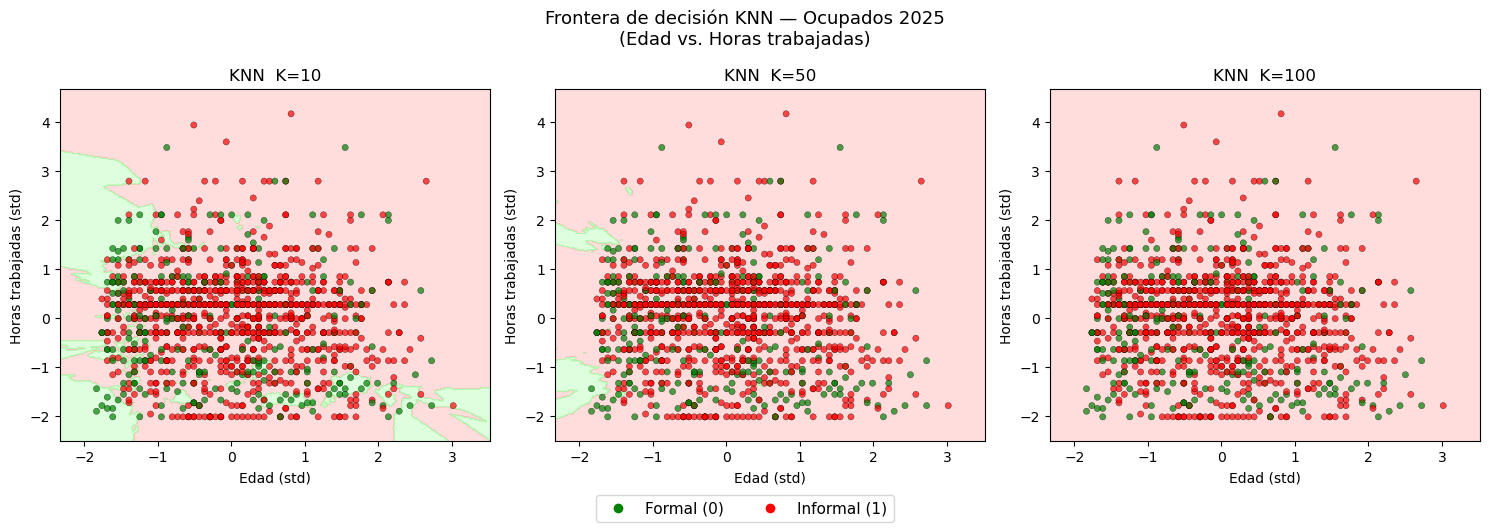

In [28]:

# Seleccionamos 2 features continuas del X_train_2025

feat2d   = ['CH06', 'horastrab']
idx      = [features.index(f) for f in feat2d]   # posiciones en el array escalado

X_train_2d = X_2025_train_scaled[:, idx]          # usamos el escalado ya hecho en C.3
y_train_2d = y_2025_train.values

# Colores 
cmap_bg     = ListedColormap(['#FFAAAA', '#AAFFAA'])   # fondo: rojo / verde
cmap_points = ListedColormap(['red', 'green'])          # puntos: informal / formal

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, k in zip(axes, [10, 50, 100]):

    # Entrenamos KNN con las 2 features
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_train_2d, y_train_2d)

    #  para la frontera 
    x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Fondo de colores según clase predicha
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)

    # Puntos del train coloreados por clase real
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
               c=y_train_2d, cmap=cmap_points,
               edgecolors='k', linewidths=0.3,
               alpha=0.7, s=20)

    ax.set_title(f'KNN  K={k}', fontsize=12)
    ax.set_xlabel('Edad (std)', fontsize=10)
    ax.set_ylabel('Horas trabajadas (std)', fontsize=10)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
           markersize=8, label='Formal (0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=8, label='Informal (1)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.06))

fig.suptitle('Frontera de decisión KNN — Ocupados 2025\n(Edad vs. Horas trabajadas)',
             fontsize=13)
plt.tight_layout()
plt.savefig('knn_fronteras_2025.png', dpi=300, bbox_inches='tight')
plt.show()

El fondo rojo dominante tiene sentido dado que informales son mayoría en la muestra. La zona verde aparece principalmente en edad baja con horas altas, que es consistente con trabajadores jóvenes a tiempo completo en el sector formal.


### 5.

K óptimo: 9  |  Accuracy CV promedio: 0.7654


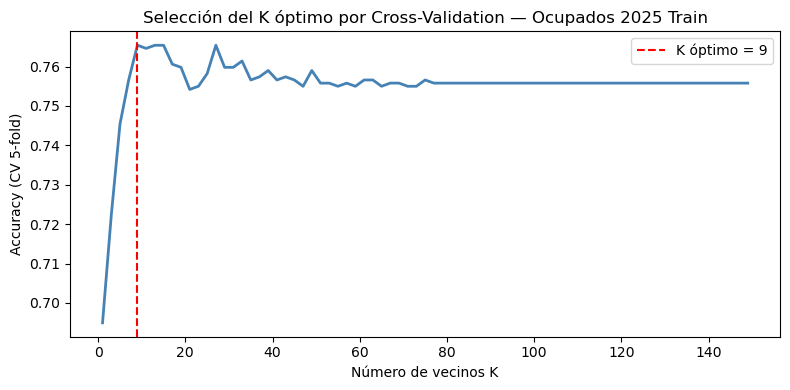

Accuracy en test: 0.7761


In [29]:

# Rango de K a evaluar
k_range = range(1, 151, 2)

scores      = {}        # diccionario 
scores_list = []        # lista

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_2025_train_scaled, y_2025_train,
                                cv=5, scoring='accuracy')
    scores[k]  = cv_scores.mean()
    scores_list.append(cv_scores.mean())

# Acá se busca el K óptimo
k_optimo = max(scores, key=scores.get)
print(f"K óptimo: {k_optimo}  |  Accuracy CV promedio: {scores[k_optimo]:.4f}")

# Gráfico 
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), scores_list, color='steelblue', linewidth=2)
plt.axvline(k_optimo, color='red', linestyle='--', linewidth=1.5,
            label=f'K óptimo = {k_optimo}')
plt.xlabel('Número de vecinos K')
plt.ylabel('Accuracy (CV 5-fold)')
plt.title('Selección del K óptimo por Cross-Validation — Ocupados 2025 Train')
plt.legend()
plt.tight_layout()
plt.savefig('knn_cv_accuracy_2025.png', dpi=300, bbox_inches='tight')
plt.show()

# Modelo final de KNN con K-CV
knn_kcv = KNeighborsClassifier(n_neighbors=k_optimo)
knn_kcv.fit(X_2025_train_scaled, y_2025_train)
print(f"Accuracy en test: {knn_kcv.score(X_2025_test_scaled, y_2025_test):.4f}")

## D. Desempeño de modelos, elección y predicción afuera de la muestra

### 6.

In [48]:

#  creamos logit_sk (sklearn) para poder usar RocCurveDisplay
logit_sk = LogisticRegression(penalty=None, max_iter=1000).fit(
    X_2025_train_scaled, y_2025_train
)
# Primero, El KFold divide X_2025_train_scaled en 5 partes, y en cada iteración usa 4 para entrenar y 1 para validar → repite 5 veces
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Probamos cada k del 1 al 150 de a 2
# Para cada k, se entrena 5 KNN distintos y se promedia su accuracy
k_scores = {}
for k in range(1, 151, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_2025_train_scaled, y_2025_train,
                            cv=kfold, scoring='accuracy').mean()
    k_scores[k] = score

# Se elige el k con mayor accuracy promedio en CV
k_optimo = max(k_scores, key=k_scores.get)

# Se entrena el KNN final con ese k sobre todo el train
knn_best = KNeighborsClassifier(n_neighbors=k_optimo).fit(
    X_2025_train_scaled, y_2025_train
)

In [49]:
# Ahora creamos las clases predichas, con un umbral 0.5 por defecto
y_pred_logit = logit_sk.predict(X_2025_test_scaled)
y_pred_knn   = knn_best.predict(X_2025_test_scaled)

# Probabilidades
y_prob_logit = logit_sk.predict_proba(X_2025_test_scaled)[:, 1]
y_prob_knn   = knn_best.predict_proba(X_2025_test_scaled)[:, 1]

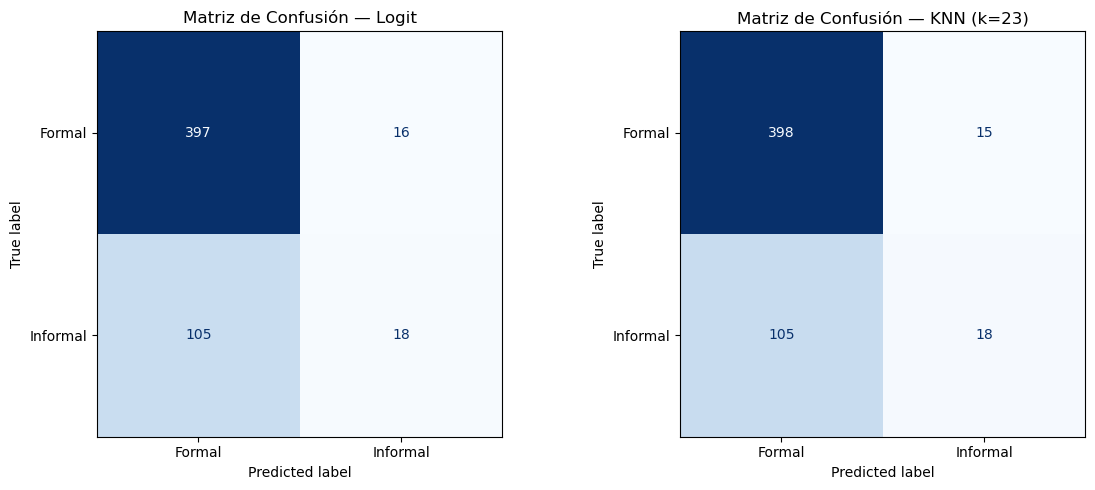

In [58]:
# Matrices de confusión 
cm_logit = confusion_matrix(y_2025_test, y_pred_logit)
tn, fp, fn, tp = cm_logit.ravel()

cm_knn = confusion_matrix(y_2025_test, y_pred_knn)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    logit_sk, X_2025_test_scaled, y_2025_test,
    display_labels=['Formal', 'Informal'],
    colorbar=False, ax=axes[0],
     cmap='Blues'
)
axes[0].set_title('Matriz de Confusión — Logit')

ConfusionMatrixDisplay.from_estimator(
    knn_kcv, X_2025_test_scaled, y_2025_test,
    display_labels=['Formal', 'Informal'],
    colorbar=False, ax=axes[1],
    cmap='Blues'   
)
axes[1].set_title(f'Matriz de Confusión — KNN (k={k_optimo})')

plt.tight_layout()
plt.savefig('matrices_confusion_2025.png', dpi=300, bbox_inches='tight')
plt.show()


In [59]:
# Agregamos las metricas 
# Accuracy: (TP+TN)/(Total)
accuracy_score(y_2025_test, y_pred_logit)

# Recall: Sensibilidad: TP/(TP+FN) 
recall_score(y_2025_test, y_pred_logit)

# AUC-ROC 
roc_auc_score(y_2025_test, y_prob_logit)


print(f"Accuracy  Logit: {accuracy_score(y_2025_test, y_pred_logit):.2f}")
print(f"Recall    Logit: {recall_score(y_2025_test, y_pred_logit):.2f}")
print(f"AUC-ROC   Logit: {roc_auc_score(y_2025_test, y_prob_logit):.2f}")

print()

print(f"Accuracy  KNN:   {accuracy_score(y_2025_test, y_pred_knn):.2f}")
print(f"Recall    KNN:   {recall_score(y_2025_test, y_pred_knn):.2f}")
print(f"AUC-ROC   KNN:   {roc_auc_score(y_2025_test, y_prob_knn):.2f}")

Accuracy  Logit: 0.77
Recall    Logit: 0.15
AUC-ROC   Logit: 0.71

Accuracy  KNN:   0.78
Recall    KNN:   0.08
AUC-ROC   KNN:   0.69


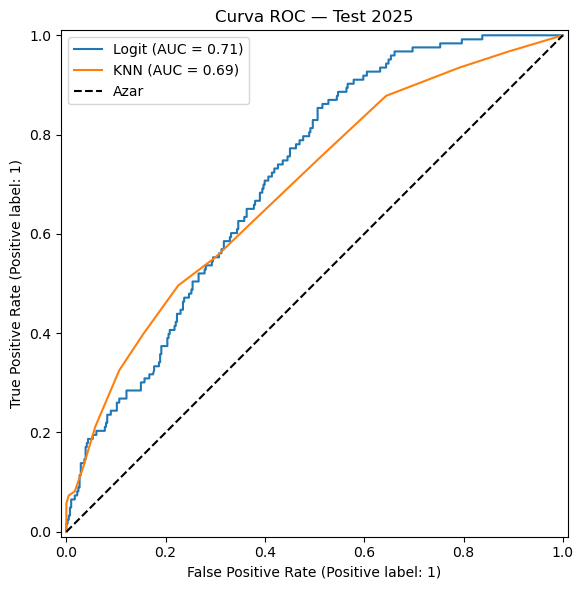

In [45]:
#Graficamos la curva ROC
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_estimator(logit_sk, X_2025_test_scaled, y_2025_test, name='Logit', ax=ax)
RocCurveDisplay.from_estimator(knn_best, X_2025_test_scaled, y_2025_test, name='KNN',  ax=ax)

ax.plot([0,1],[0,1], 'k--', label='Azar')
ax.set_title('Curva ROC — Test 2025')
plt.legend()
plt.tight_layout()
plt.savefig('curva_roc_2025.png', dpi=300, bbox_inches='tight') 
plt.show()

### 7. 

In [46]:
#Realizado en Notebook

## E. Herramientas de IA y reflexión final

Realizado en Documento de LaTeX. 